In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

tickers = [
    "ADANIENT.NS", "ADANIPORTS.NS", "APOLLOHOSP.NS", "ASIANPAINT.NS", "AXISBANK.NS",
    "BAJAJ-AUTO.NS", "BAJAJFINSV.NS", "BAJFINANCE.NS", "BEL.NS", "BHARTIARTL.NS",
    "CIPLA.NS", "COALINDIA.NS", "DRREDDY.NS", "EICHERMOT.NS", "GRASIM.NS",
    "HCLTECH.NS", "HDFCBANK.NS", "HINDALCO.NS", "HINDUNILVR.NS",
    "ICICIBANK.NS", "INDIGO.NS", "INDUSINDBK.NS", "INFY.NS", "ITC.NS", 
    "JSWSTEEL.NS", "KOTAKBANK.NS", "LT.NS", "M&M.NS", 
    "MARUTI.NS", "NESTLEIND.NS", "NTPC.NS", "ONGC.NS", 
    "POWERGRID.NS", "RELIANCE.NS", "SBIN.NS", "SHRIRAMFIN.NS", 
    "SUNPHARMA.NS", "TATACONSUM.NS", "TATASTEEL.NS", "TCS.NS", "TECHM.NS", 
    "TITAN.NS", "TRENT.NS", "ULTRACEMCO.NS", "WIPRO.NS"
]

df = pd.read_csv('StocksData.csv')
close_cols = [col for col in df.columns if str(col).startswith('Close')][:45]
df_close = df[['Price']+close_cols].iloc[2:].copy()
df_close.columns = ['Date'] + tickers
df_close = df_close.set_index('Date',drop=True).astype(float)
df_close.index = pd.to_datetime(df_close.index, format="%d-%m-%Y")
df_returns = df_close.pct_change().dropna()

In [3]:
df_returns

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,-0.055494,-0.035881,-0.007325,0.002333,-0.025561,-0.013761,-0.012249,-0.007120,-0.004143,-0.040235,...,-0.028647,-0.020170,-0.018443,-0.001943,-0.019368,-0.007018,-0.001846,-0.025583,-0.026505,0.002246
2016-01-05,0.041128,-0.008723,0.012689,0.022537,-0.004448,0.007651,-0.006890,-0.009021,-0.002846,-0.010251,...,0.028541,0.001752,0.032359,0.067731,-0.008714,0.010651,-0.010529,-0.015542,-0.005856,-0.001434
2016-01-06,-0.026524,-0.015252,-0.008955,-0.015822,-0.013175,-0.006734,-0.003828,0.018240,-0.009333,-0.003865,...,0.008903,-0.010681,-0.020897,-0.020233,0.013900,0.006131,0.000431,-0.017036,0.000823,-0.003232
2016-01-07,-0.073043,-0.027005,-0.040334,-0.015851,-0.049803,-0.026655,-0.005932,-0.000156,-0.044037,0.000466,...,-0.058503,-0.010291,-0.035800,-0.070140,-0.004346,-0.027233,-0.010924,-0.016152,-0.024714,-0.009458
2016-01-08,0.025641,-0.014694,0.005656,0.002579,0.010874,-0.017939,0.038063,0.034096,0.003285,0.004653,...,0.024831,0.013205,0.031417,0.014806,0.011112,0.022220,0.011481,0.052418,0.014057,0.010821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,-0.011606,0.000469,0.013925,-0.007942,0.001061,0.007803,-0.005812,0.000297,0.001502,0.000377,...,0.016601,-0.010764,-0.005398,-0.004857,0.002719,-0.000919,-0.004203,0.023918,0.007364,-0.012306
2025-12-26,0.003239,-0.004818,-0.002231,-0.014001,0.001549,-0.011505,-0.008891,-0.011565,-0.003875,-0.008617,...,-0.013813,-0.010075,-0.002968,-0.005586,-0.011751,-0.011768,0.021155,-0.001002,0.002550,-0.006566
2025-12-29,-0.011974,-0.021989,-0.009992,0.010522,0.003094,0.002482,-0.002726,-0.002000,-0.013051,-0.011304,...,-0.004947,-0.001338,0.016586,0.018803,-0.008689,0.000062,-0.002079,-0.013838,0.000424,-0.007736


In [4]:
T, N = df_returns.shape
Q = T / N

# 1. Standardize the returns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_returns)

# 2. Compute the empirical correlation matrix
corr_matrix = np.corrcoef(X_scaled, rowvar=False)

# 3. Calculate Eigenvalues and sort them descending
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
eigenvalues = np.sort(eigenvalues)[::-1]

# 4. Calculate Marchenko-Pastur theoretical upper bound
# For a correlation matrix, the average variance (sigma^2) is 1 - var explained by highest eigen value
sigma_squared = 1 - eigenvalues[0]/N
lambda_max = sigma_squared * (1 + np.sqrt(1/Q))**2

# 5. Hypothesis Test: Count how many PCs beat the noise threshold
signal_eigenvalues = eigenvalues[eigenvalues > lambda_max]
optimal_k = len(signal_eigenvalues)

print("="*50)
print("RANDOM MATRIX THEORY: EIGENVALUE HYPOTHESIS TEST")
print("="*50)
print(f"Matrix Dimensions:        T = {T} days, N = {N} stocks")
print(f"Theoretical Noise Bound:  Lambda Max = {lambda_max:.4f}")
print("-" * 50)
print(f"Number of PCs > Noise:    {optimal_k}")
print(f"Variance Explained by {optimal_k} PCs: {(np.sum(signal_eigenvalues) / N * 100):.2f}%")
print("="*50)

# Print the top eigenvalues to see the cutoff
for i, val in enumerate(eigenvalues[:optimal_k + 3]):
    status = "SIGNAL" if val > lambda_max else "NOISE"
    print(f"PC {i+1}: Eigenvalue = {val:.4f}  [{status}]")

RANDOM MATRIX THEORY: EIGENVALUE HYPOTHESIS TEST
Matrix Dimensions:        T = 2469 days, N = 45 stocks
Theoretical Noise Bound:  Lambda Max = 0.8957
--------------------------------------------------
Number of PCs > Noise:    9
Variance Explained by 9 PCs: 56.25%
PC 1: Eigenvalue = 13.7120  [SIGNAL]
PC 2: Eigenvalue = 2.5648  [SIGNAL]
PC 3: Eigenvalue = 2.0252  [SIGNAL]
PC 4: Eigenvalue = 1.6353  [SIGNAL]
PC 5: Eigenvalue = 1.2671  [SIGNAL]
PC 6: Eigenvalue = 1.1051  [SIGNAL]
PC 7: Eigenvalue = 1.0539  [SIGNAL]
PC 8: Eigenvalue = 1.0012  [SIGNAL]
PC 9: Eigenvalue = 0.9497  [SIGNAL]
PC 10: Eigenvalue = 0.8913  [NOISE]
PC 11: Eigenvalue = 0.8716  [NOISE]
PC 12: Eigenvalue = 0.8189  [NOISE]


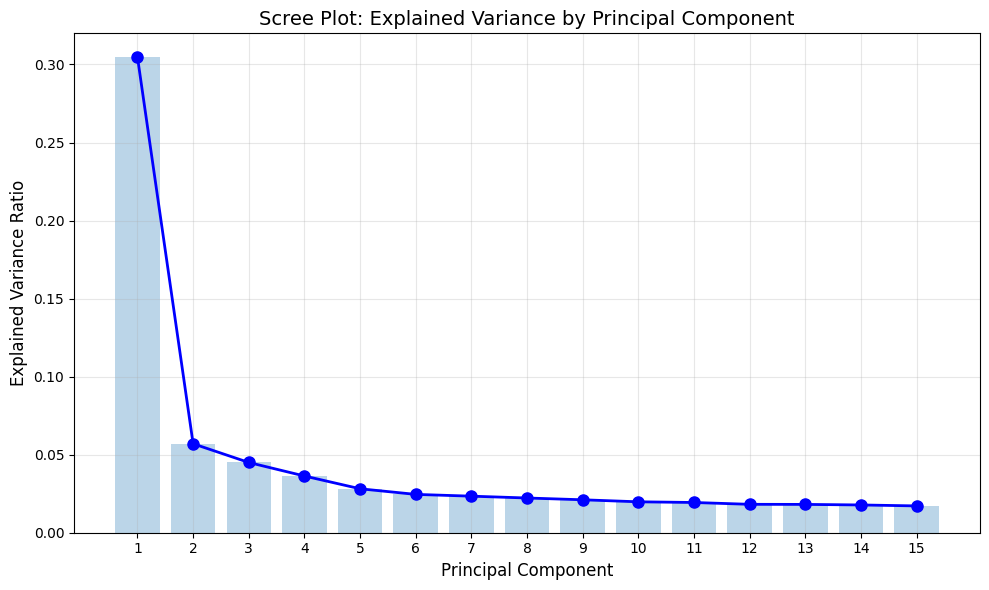

Explained Variance by Top 5 PCs: 0.4712102229774191

First 5 Stocks and their PC Loadings:
                    PC1       PC2       PC3       PC4       PC5
ADANIENT.NS    0.144180 -0.062694  0.093972 -0.005296 -0.026508
ADANIPORTS.NS  0.162351 -0.065939  0.101646 -0.020643 -0.037505
APOLLOHOSP.NS  0.111913  0.069126 -0.052276  0.189274  0.075660
ASIANPAINT.NS  0.134925  0.041369 -0.264576  0.147154 -0.224344
AXISBANK.NS    0.178191 -0.121732 -0.074001 -0.157878  0.187049


In [5]:
# ==========================================
# 2. STANDARDIZE RETURNS
# ==========================================
# PCA is highly sensitive to variance. We must standardize so high-volatility 
# stocks don't artificially dominate the principal components.
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(df_returns)

# ==========================================
# 3. FIT PCA & EXTRACT LOADINGS
# ==========================================
n_components = 15
pca = PCA(n_components=n_components)
pca.fit(scaled_returns)

# Create a scree plot to visualize explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_components + 1), pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
plt.bar(range(1, n_components + 1), pca.explained_variance_ratio_, alpha=0.3)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Scree Plot: Explained Variance by Principal Component', fontsize=14)
plt.xticks(range(1, n_components + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Let's extract the top 5 Principal Components
n_components = 5
pca = PCA(n_components=n_components)
pca.fit(scaled_returns)

# pca.components_ shape is (n_components, num_stocks) -> (5, 50)
# We transpose it to get (num_stocks, n_components) -> (50, 5)
# Now, every stock is represented by a vector of 5 PC loadings.
loadings_matrix = pca.components_.T 

df_loadings = pd.DataFrame(
    loadings_matrix, 
    index=df_returns.columns, 
    columns=[f"PC{i+1}" for i in range(n_components)]
)

print("Explained Variance by Top 5 PCs:", pca.explained_variance_ratio_.sum())
print("\nFirst 5 Stocks and their PC Loadings:")
print(df_loadings.head())

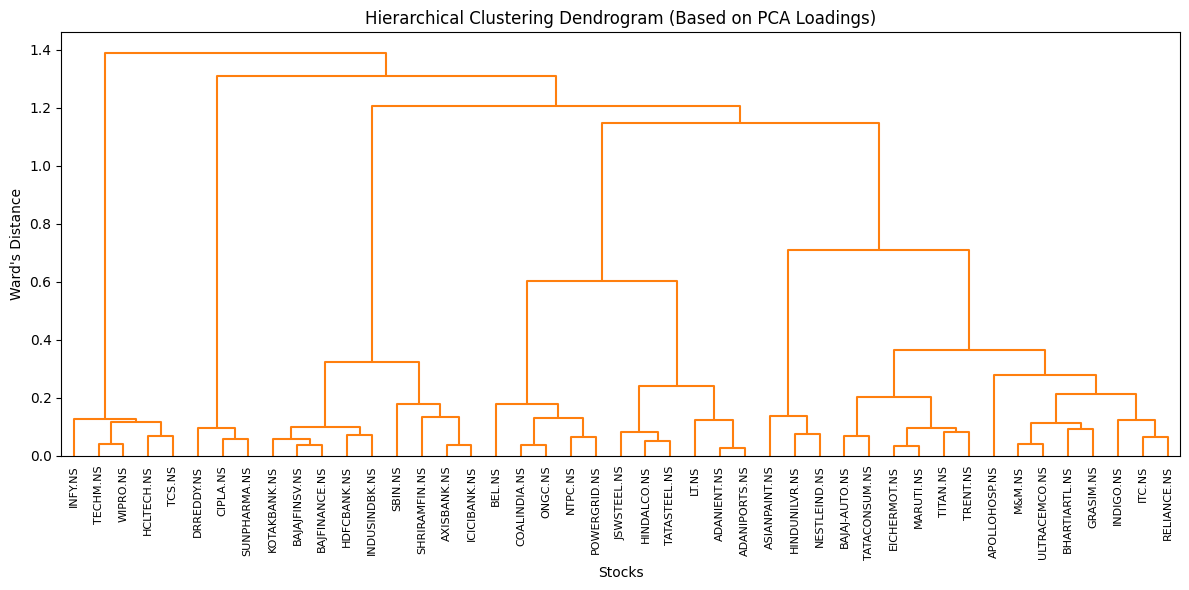


CLUSTER SEPARATION DIAGNOSTICS
Silhouette Score:           0.5188 (Higher is better)
Calinski-Harabasz Index:    48.3935 (Higher is better)
Davies-Bouldin Index:       0.6311 (Lower is better)

--- Specific Cluster Breakdown ---
Cluster 1:  5 stocks | WCSS: 0.0180 | Avg Variance: 0.0036
Cluster 2:  3 stocks | WCSS: 0.0066 | Avg Variance: 0.0022
Cluster 3:  9 stocks | WCSS: 0.0879 | Avg Variance: 0.0098
Cluster 4: 11 stocks | WCSS: 0.2503 | Avg Variance: 0.0228
Cluster 5:  3 stocks | WCSS: 0.0123 | Avg Variance: 0.0041
Cluster 6: 14 stocks | WCSS: 0.1819 | Avg Variance: 0.0130
-----------------------------------------
Total Within-Cluster Variance (WCSS):  0.5569 (Keep Low)
Total Between-Cluster Variance (BCSS): 3.4555 (Keep High)
Total Variance (WCSS + BCSS):          4.0124

% Variance Explained by Clusters:      86.12%


In [6]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
# ==========================================
# 4. HIERARCHICAL CLUSTERING ON LOADINGS
# ==========================================
Z = linkage(df_loadings, method='ward')

# ==========================================
# 5. VISUALIZATION & LABEL EXTRACTION
# ==========================================
plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram (Based on PCA Loadings)")
plt.xlabel("Stocks")
plt.ylabel("Ward's Distance")

# Draw the dendrogram
dendrogram(
    Z,
    labels=df_loadings.index,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=3.5 
)
plt.tight_layout()
plt.show()

# Extract actual cluster labels
num_clusters = 6
cluster_labels = fcluster(Z, t=num_clusters, criterion='maxclust')

df_clusters = pd.DataFrame({
    'Stock': df_loadings.index,
    'Cluster': cluster_labels
})

# ==========================================
# 6. CLUSTER DIAGNOSTICS & SEPARATION METRICS
# ==========================================
print("\n" + "="*45)
print("CLUSTER SEPARATION DIAGNOSTICS")
print("="*45)

# 1. Global Metrics (Scikit-Learn)
# Silhouette: [-1 to +1]. Measures distance to own cluster vs nearest neighboring cluster. >0.3 is decent for financial data.
sil_score = silhouette_score(df_loadings, cluster_labels)
# Calinski-Harabasz: Ratio of Between-Cluster Variance to Within-Cluster Variance. Higher is better.
ch_score = calinski_harabasz_score(df_loadings, cluster_labels)
# Davies-Bouldin: Average similarity measure of each cluster with its most similar cluster. Lower is better.
db_score = davies_bouldin_score(df_loadings, cluster_labels)

print(f"Silhouette Score:           {sil_score:.4f} (Higher is better)")
print(f"Calinski-Harabasz Index:    {ch_score:.4f} (Higher is better)")
print(f"Davies-Bouldin Index:       {db_score:.4f} (Lower is better)\n")

# 2. Manual Variance Calculations (WCSS & BCSS)
global_centroid = df_loadings.mean(axis=0).values
total_wcss = 0
bcss = 0

print("--- Specific Cluster Breakdown ---")
for cluster_id in range(1, num_clusters + 1):
    # Isolate stocks in this cluster
    cluster_mask = cluster_labels == cluster_id
    cluster_points = df_loadings[cluster_mask].values
    cluster_size = len(cluster_points)
    
    # Calculate Cluster Centroid
    cluster_centroid = cluster_points.mean(axis=0)
    
    # Calculate Within-Cluster Sum of Squares (WCSS) for this cluster
    # (Sum of squared distances from each point to its own centroid)
    wcss_k = np.sum((cluster_points - cluster_centroid) ** 2)
    total_wcss += wcss_k
    
    # Calculate Between-Cluster Sum of Squares (BCSS) contribution
    # (Size of cluster * squared distance from cluster centroid to global centroid)
    bcss_k = cluster_size * np.sum((cluster_centroid - global_centroid) ** 2)
    bcss += bcss_k
    
    # Calculate variance (Mean Squared Error) for context
    cluster_variance = wcss_k / cluster_size if cluster_size > 0 else 0
    
    print(f"Cluster {cluster_id}: {cluster_size:2d} stocks | WCSS: {wcss_k:.4f} | Avg Variance: {cluster_variance:.4f}")

print("-" * 41)
print(f"Total Within-Cluster Variance (WCSS):  {total_wcss:.4f} (Keep Low)")
print(f"Total Between-Cluster Variance (BCSS): {bcss:.4f} (Keep High)")
print(f"Total Variance (WCSS + BCSS):          {(total_wcss + bcss):.4f}")
# Calculate Variance Explained by Clusters (R-squared of Clustering)
r_squared = bcss / (total_wcss + bcss)
print(f"\n% Variance Explained by Clusters:      {(r_squared * 100):.2f}%")

In [7]:
from sklearn.cluster import KMeans

# ==========================================
# 1. K-MEANS CLUSTERING
# ==========================================
# Assuming df_loadings is already created (e.g., 50 stocks x 5 PCs)
num_clusters = 6

# Initialize and fit K-Means
# n_init='auto' is the modern sklearn standard; random_state ensures reproducibility
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(df_loadings)

# Create a DataFrame for the results
df_kmeans = pd.DataFrame({
    'Stock': df_loadings.index,
    'Cluster': cluster_labels + 1  # +1 so clusters are 1, 2, 3, 4 instead of 0, 1, 2, 3
})

# ==========================================
# 2. DIAGNOSTICS & METRICS
# ==========================================
print("\n" + "="*50)
print("K-MEANS CLUSTER SEPARATION DIAGNOSTICS")
print("="*50)

# A. Global Scikit-Learn Metrics
sil_score = silhouette_score(df_loadings, cluster_labels)
ch_score = calinski_harabasz_score(df_loadings, cluster_labels)
db_score = davies_bouldin_score(df_loadings, cluster_labels)

print(f"Silhouette Score:           {sil_score:.4f} (Target: > 0.3)")
print(f"Calinski-Harabasz Index:    {ch_score:.4f} (Higher is better)")
print(f"Davies-Bouldin Index:       {db_score:.4f} (Lower is better)\n")

# B. Variance Diagnostics (WCSS & BCSS)
# K-Means gives us WCSS directly via the 'inertia_' attribute
wcss = kmeans.inertia_

# To find Total Variance, we calculate the variance of all points from the global mean
global_mean = df_loadings.mean(axis=0).values
total_variance = np.sum((df_loadings.values - global_mean) ** 2)

# BCSS is simply Total Variance minus WCSS
bcss = total_variance - wcss
r_squared = bcss / total_variance

print("--- Variance Breakdown ---")
print(f"Total Within-Cluster Variance (WCSS):  {wcss:.4f} (Algorithm minimized this)")
print(f"Total Between-Cluster Variance (BCSS): {bcss:.4f}")
print(f"Total System Variance:                 {total_variance:.4f}")
print(f"% Variance Explained by Clusters:      {(r_squared * 100):.2f}%\n")

# C. Cluster-Specific Breakdown
centroids = kmeans.cluster_centers_

print("--- Cluster Profiles ---")
for k in range(num_clusters):
    cluster_mask = cluster_labels == k
    size = np.sum(cluster_mask)
    
    # Calculate WCSS specifically for this cluster
    cluster_points = df_loadings[cluster_mask].values
    cluster_wcss = np.sum((cluster_points - centroids[k]) ** 2)
    
    print(f"Cluster {k+1}: {size:2d} stocks | Internal WCSS: {cluster_wcss:.4f}")


K-MEANS CLUSTER SEPARATION DIAGNOSTICS
Silhouette Score:           0.5189 (Target: > 0.3)
Calinski-Harabasz Index:    49.8272 (Higher is better)
Davies-Bouldin Index:       0.6153 (Lower is better)

--- Variance Breakdown ---
Total Within-Cluster Variance (WCSS):  0.5431 (Algorithm minimized this)
Total Between-Cluster Variance (BCSS): 3.4693
Total System Variance:                 4.0124
% Variance Explained by Clusters:      86.46%

--- Cluster Profiles ---
Cluster 1: 10 stocks | Internal WCSS: 0.2034
Cluster 2:  5 stocks | Internal WCSS: 0.0180
Cluster 3:  3 stocks | Internal WCSS: 0.0123
Cluster 4:  3 stocks | Internal WCSS: 0.0066
Cluster 5: 10 stocks | Internal WCSS: 0.1209
Cluster 6: 14 stocks | Internal WCSS: 0.1819


In [8]:
import plotly.express as px
import plotly.graph_objects as go

# Assuming df_loadings is already created and contains PC1, PC2, PC3
num_clusters = 6
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(df_loadings[['PC1', 'PC2', 'PC3']]) # Fit on top 3 for exact visual match
centroids = kmeans.cluster_centers_

# Add labels back to the dataframe for hover data
df_plot = df_loadings.copy()
df_plot['Cluster'] = (cluster_labels + 1).astype(str) # Convert to string for discrete coloring
df_plot['Stock'] = df_plot.index

# ==========================================
# GENERATE INTERACTIVE 3D SCATTER PLOT
# ==========================================
# 1. Plot the individual stocks
fig = px.scatter_3d(
    df_plot, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Cluster',
    hover_name='Stock', # Shows the stock ticker when you hover!
    title="3D Market Structure (PC1 vs PC2 vs PC3)",
    color_discrete_sequence=px.colors.qualitative.Plotly,
    opacity=0.7
)

# 2. Add the mathematical centroids as large black X markers
fig.add_trace(
    go.Scatter3d(
        x=centroids[:, 0],
        y=centroids[:, 1],
        z=centroids[:, 2],
        mode='markers',
        marker=dict(
            size=10,
            color='black',
            symbol='x',
            line=dict(color='white', width=2)
        ),
        name='Centroids',
        hoverinfo='name'
    )
)

# 3. Clean up the layout and grid
fig.update_layout(
    scene=dict(
        xaxis_title='PC1 (Market Factor)',
        yaxis_title='PC2 (Sector Factor A)',
        zaxis_title='PC3 (Sector Factor B)',
        bgcolor='rgb(240, 240, 240)'
    ),
    margin=dict(l=0, r=0, b=0, t=40) # Removes excess white space
)

# Display the interactive plot in your notebook
fig.show()

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. DATA COLLECTION
# ==========================================
print("Fetching Market Data...")
tickers = {
    "^NSEI": "NIFTY",
    "^INDIAVIX": "VIX",
    "INR=X": "USD_INR",
    "CL=F": "CRUDE_OIL"
}

data_frames = []
for ticker, name in tickers.items():
    df = yf.download(ticker, start="2016-01-01", end="2026-01-01", progress=False)['Close']
    df.name = name
    data_frames.append(df)

market_data = pd.concat(data_frames, axis=1).dropna()
# Forward fill missing alternate data (holidays misalignments), drop hard NaNs
market_data = market_data.ffill()

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
print("Engineering Features...")
features = pd.DataFrame(index=market_data.index)

# A. Core Returns
features['Close'] = market_data['^NSEI']

# D. Alternate Data Returns
features['VIX'] = market_data['^INDIAVIX']
features['USD_INR_Ret'] = np.log(market_data['INR=X'] / market_data['INR=X'].shift(1))
features['Oil'] = market_data['CL=F']

# Drop NaN rows created by rolling windows and shifts
features = features.dropna()

print(f"Feature Space Built: {features.shape[0]} days, {features.shape[1]} features.")

Fetching Market Data...
Engineering Features...
Feature Space Built: 2380 days, 4 features.


In [10]:
features

,Close,VIX,USD_INR_Ret,Oil
Date,,,,
2016-01-05,7784.649902,16.700001,0.006145,35.970001
2016-01-06,7741.000000,16.549999,-0.001157,33.970001
2016-01-07,7568.299805,18.959999,0.003002,33.270000
2016-01-08,7601.350098,17.799999,0.002948,33.160000
2016-01-11,7563.850098,18.690001,-0.001211,31.410000
...,...,...,...,...
2025-12-24,26142.099609,9.190000,-0.001072,58.349998
2025-12-26,26042.300781,9.150000,0.006659,56.740002
2025-12-29,25942.099609,9.720000,-0.003074,58.080002


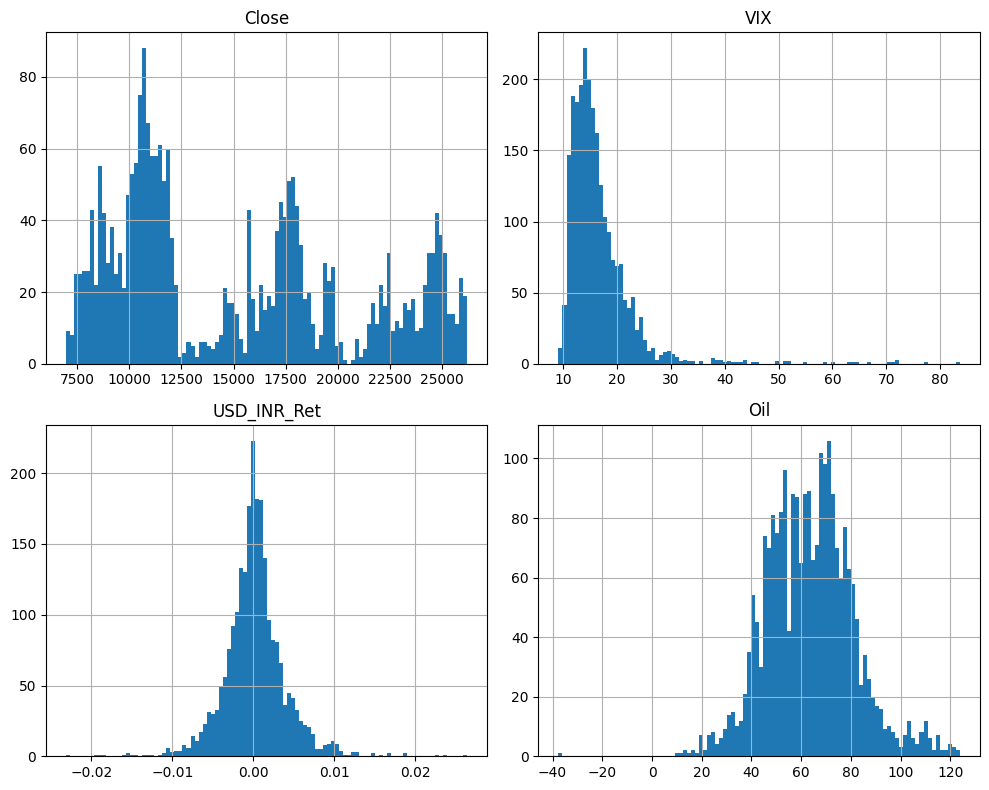

In [11]:
features.hist(figsize=(10, 8), bins=100)
plt.tight_layout()
plt.show()

--- Regime Diagnostics ---
                  Days_in_Regime  Ann_Return  Ann_Vol  Ann_Sharpe  Mean_VIX  \
Regime_Name                                                                   
1. Bull Calm                1036      0.2609   0.1042      2.5050   13.8246   
2. Bull Volatile             480      0.1445   0.1717      0.8414   20.3756   
3. Bear Calm                 499      0.0825   0.1268      0.6503   14.2704   
4. Bear Volatile             339     -0.1520   0.3023     -0.5030   22.6631   

                  Mean_Oil_Return  
Regime_Name                        
1. Bull Calm              -0.0011  
2. Bull Volatile           0.0063  
3. Bear Calm              -0.0025  
4. Bear Volatile           0.0020  


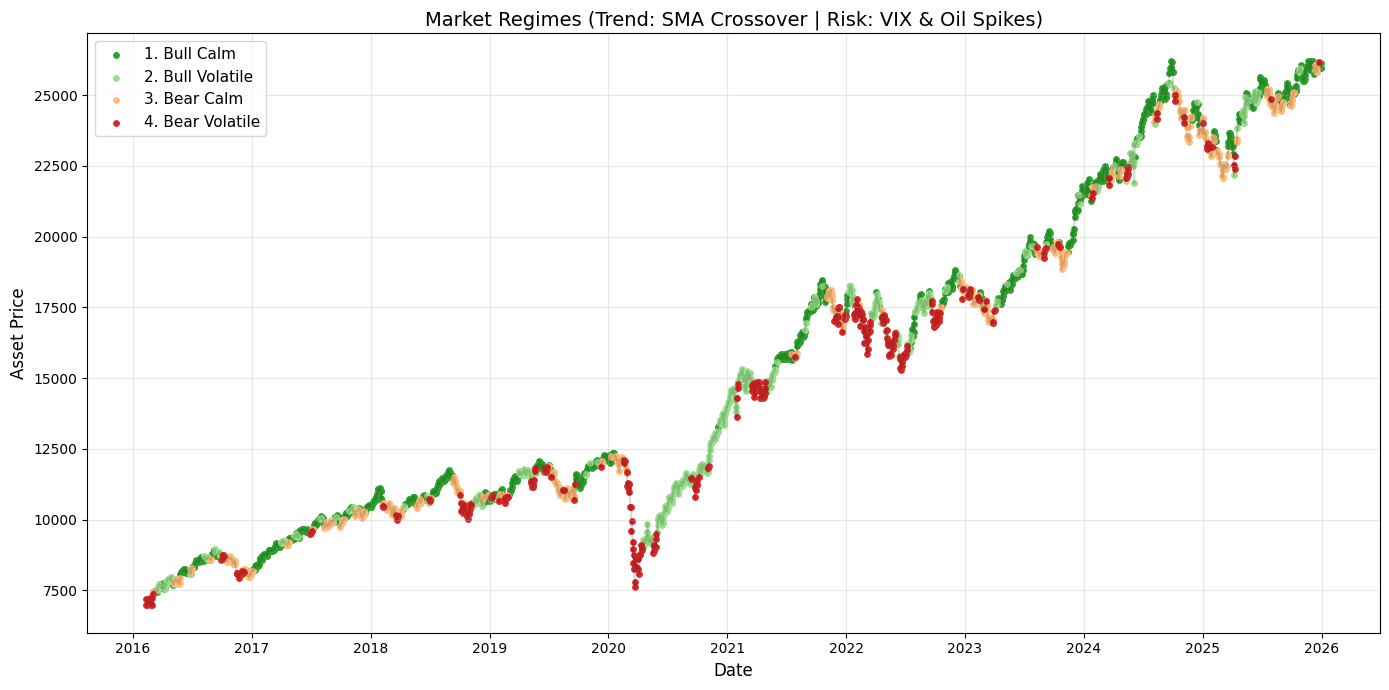

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df' and has columns: 'Close', 'VIX', 'Oil'

# =====================================================================
# 1. FEATURE ENGINEERING
# =====================================================================
df = features.copy()
# Calculate Returns
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df['Oil_Returns'] = np.log(df['Oil'] / df['Oil'].shift(1))

# Trend Indicators (5-day and 25-day SMA) Weekly vs Monthly
df['SMA10'] = df['Close'].rolling(window=5).mean()
df['SMA50'] = df['Close'].rolling(window=25).mean()

# Drop NaNs generated by the rolling windows
df = df.dropna()

# =====================================================================
# 2. DEFINE REGIMES USING VIX & OIL
# =====================================================================

# Risk Thresholds
# We use the 75th percentile of VIX as the "High Volatility" baseline
vix_thresh = df['VIX'].quantile(0.75)

# Macro Overlay: If Oil spikes more than 5% over 5 days, we flag a risk event
df['Oil_Spike'] = df['Oil'].pct_change(5) > 0.05

# Trend Condition: 1 if Bullish (Fast SMA > Slow SMA), 0 if Bearish
trend = np.where(df['SMA10'] > df['SMA50'], 1, 0)

# Volatility Condition: 1 if High Risk (VIX is high OR Oil is spiking)
volatility = np.where((df['VIX'] > vix_thresh) | (df['Oil_Spike']), 1, 0)

# Initialize Regimes array
df['Regime'] = np.zeros(len(df), dtype=int)

# Map conditions to your 4 Regimes
df.loc[(trend == 1) & (volatility == 0), 'Regime'] = 1 # Bull Calm
df.loc[(trend == 1) & (volatility == 1), 'Regime'] = 2 # Bull Volatile
df.loc[(trend == 0) & (volatility == 0), 'Regime'] = 3 # Bear Calm
df.loc[(trend == 0) & (volatility == 1), 'Regime'] = 4 # Bear Volatile

# Add string names for easier reading
df['Regime_Name'] = df['Regime'].map({
    1: '1. Bull Calm', 
    2: '2. Bull Volatile', 
    3: '3. Bear Calm', 
    4: '4. Bear Volatile'
})

# =====================================================================
# 3. REGIME DIAGNOSTICS
# =====================================================================

diagnostics = df.groupby('Regime_Name').agg(
    Days_in_Regime=('Returns', 'count'),
    Mean_Daily_Return=('Returns', 'mean'),
    Daily_Vol=('Returns', 'std'),
    Mean_VIX=('VIX', 'mean'),
    Mean_Oil_Return=('Oil_Returns', 'mean')
)

# Annualize metrics for standard reporting
diagnostics['Ann_Return'] = diagnostics['Mean_Daily_Return'] * 252
diagnostics['Ann_Vol'] = diagnostics['Daily_Vol'] * np.sqrt(252)
diagnostics['Ann_Sharpe'] = diagnostics['Ann_Return'] / diagnostics['Ann_Vol']

display_cols = ['Days_in_Regime', 'Ann_Return', 'Ann_Vol', 'Ann_Sharpe', 'Mean_VIX', 'Mean_Oil_Return']
print("--- Regime Diagnostics ---")
print(diagnostics[display_cols].round(4))

# =====================================================================
# 4. PLOTTING
# =====================================================================

plt.figure(figsize=(14, 7))
# Colors: Green (Bull Calm), Light Green (Bull Vol), Orange (Bear Calm), Red (Bear Vol)
colors = {1: '#2ca02c', 2: '#98df8a', 3: '#ffbb78', 4: '#d62728'} 

# Plot the underlying stock line faintly
plt.plot(df.index, df['Close'], color='black', alpha=0.15, linewidth=1.5)

# Overlay the regimes as colored scatter points
for r in [1, 2, 3, 4]:
    mask = df['Regime'] == r
    name = df[mask]['Regime_Name'].iloc[0]
    plt.scatter(df.index[mask], df['Close'][mask], color=colors[r], label=name, s=15)

plt.title('Market Regimes (Trend: SMA Crossover | Risk: VIX & Oil Spikes)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Asset Price', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 0. DATA ALIGNMENT
# =====================================================================
# ASSUMPTION: You have a dataframe 'df_stock_returns' containing the daily 
# returns of your 50 stocks. We must align its dates with your macro 'df'.

# Example alignment (replace 'df_stock_returns' with your actual variable)
valid_dates = df.index.intersection(df_returns.index)
macro_df = df.loc[valid_dates]
returns_df = df_returns.loc[valid_dates]

# FOR THIS SCRIPT: Let's assume 'macro_df' and 'returns_df' are perfectly aligned.
NUM_CLUSTERS = 6
NUM_PCS = 5

print("="*60)
print("CLUSTERING DIAGNOSTICS: MACRO RULES-BASED REGIMES")
print("="*60)

# =====================================================================
# 1. COMPUTE THE STATIC BASELINE (10-Year View)
# =====================================================================
scaler = StandardScaler()
X_static = scaler.fit_transform(returns_df)
pca_static = PCA(n_components=NUM_PCS, random_state=42)
loadings_static = pca_static.fit(X_static).components_.T

kmeans_static = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
static_labels = kmeans_static.fit_predict(loadings_static)

# =====================================================================
# 2. REGIME-WISE EVALUATION
# =====================================================================
regime_names = {
    1: '1. Bull Calm', 
    2: '2. Bull Volatile', 
    3: '3. Bear Calm', 
    4: '4. Bear Volatile'
}

diagnostic_results = []

for r in [1, 2, 3, 4]:
    # Slice the stock returns for the days this regime was active
    mask = macro_df['Regime'] == r
    regime_returns = returns_df[mask]
    
    # Failsafe: Need enough days to run a valid PCA correlation matrix
    if len(regime_returns) < 40:
        print(f"Skipping Regime {r} ({regime_names[r]}): Only {len(regime_returns)} days (too few for PCA).")
        continue
        
    # A. Regime-Specific PCA & Clustering
    X_regime = StandardScaler().fit_transform(regime_returns)
    pca_regime = PCA(n_components=NUM_PCS, random_state=42)
    loadings_regime = pca_regime.fit(X_regime).components_.T
    
    kmeans_regime = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
    regime_labels = kmeans_regime.fit_predict(loadings_regime)
    
    # B. Separation Metrics
    db_score = davies_bouldin_score(loadings_regime, regime_labels)
    sil_score = silhouette_score(loadings_regime, regime_labels)
    
    # C. Structural Drift (Current Regime vs 10-Year Static Baseline)
    # Because 'regime_labels' and 'static_labels' both contain exactly 50 stocks,
    # we can compare them directly to see if the stocks changed alliances.
    ari_vs_static = adjusted_rand_score(static_labels, regime_labels)
    
    # D. Temporal Stability (Half 1 vs Half 2 of the Regime)
    midpoint = len(regime_returns) // 2
    h1_returns = regime_returns.iloc[:midpoint]
    h2_returns = regime_returns.iloc[midpoint:]
    
    # Only run temporal test if we have enough days in both halves
    if len(h1_returns) >= 20 and len(h2_returns) >= 20:
        # Half 1
        X_h1 = StandardScaler().fit_transform(h1_returns)
        loadings_h1 = PCA(n_components=NUM_PCS, random_state=42).fit(X_h1).components_.T
        labels_h1 = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10).fit_predict(loadings_h1)
        
        # Half 2
        X_h2 = StandardScaler().fit_transform(h2_returns)
        loadings_h2 = PCA(n_components=NUM_PCS, random_state=42).fit(X_h2).components_.T
        labels_h2 = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10).fit_predict(loadings_h2)
        
        ari_temporal = adjusted_rand_score(labels_h1, labels_h2)
    else:
        ari_temporal = np.nan

    diagnostic_results.append({
        'Regime': regime_names[r],
        'Days': len(regime_returns),
        'DB_Score': round(db_score, 4),
        'ARI_vs_Static': round(ari_vs_static, 4),
        'ARI_Temporal': round(ari_temporal, 4)
    })

# =====================================================================
# 3. DISPLAY RESULTS
# =====================================================================
results_df = pd.DataFrame(diagnostic_results).set_index('Regime')

print("\n--- CLUSTER QUALITY & SEPARATION ---")
print("Davies-Bouldin (Lower is better: tighter, more distinct spheres)")
print(results_df[['Days', 'DB_Score']])

print("\n--- STRUCTURAL SHIFT & DRIFT ---")
print("ARI vs Static (Lower = Clusters broke down compared to 10-yr baseline)")
print(results_df[['ARI_vs_Static']])

print("\n--- TEMPORAL STABILITY ---")
print("ARI (Half 1 vs Half 2) (Higher = Structure remains stable over time)")
print(results_df[['ARI_Temporal']])

CLUSTERING DIAGNOSTICS: MACRO RULES-BASED REGIMES

--- CLUSTER QUALITY & SEPARATION ---
Davies-Bouldin (Lower is better: tighter, more distinct spheres)
                  Days  DB_Score
Regime                          
1. Bull Calm      1036    0.7037
2. Bull Volatile   480    0.6970
3. Bear Calm       499    0.7771
4. Bear Volatile   339    0.8003

--- STRUCTURAL SHIFT & DRIFT ---
ARI vs Static (Lower = Clusters broke down compared to 10-yr baseline)
                  ARI_vs_Static
Regime                         
1. Bull Calm             0.3410
2. Bull Volatile         0.5120
3. Bear Calm             0.4339
4. Bear Volatile         0.6385

--- TEMPORAL STABILITY ---
ARI (Half 1 vs Half 2) (Higher = Structure remains stable over time)
                  ARI_Temporal
Regime                        
1. Bull Calm            0.3490
2. Bull Volatile        0.2759
3. Bear Calm            0.4514
4. Bear Volatile        0.2108


RUNNING ROLLING REGIME-WISE DIAGNOSTICS (WITH LABEL ALIGNMENT)

--- AVERAGE ROLLING METRICS PER REGIME ---
                  Rolling_DB_Score  Rolling_Silhouette  Avg_Daily_Turnover(%)
Regime                                                                       
1. Bull Calm                0.9052              0.3567                13.8989
2. Bull Volatile            0.9176              0.3531                16.5309
3. Bear Calm                0.9685              0.3185                17.8313
4. Bear Volatile            0.9745              0.3086                21.2771


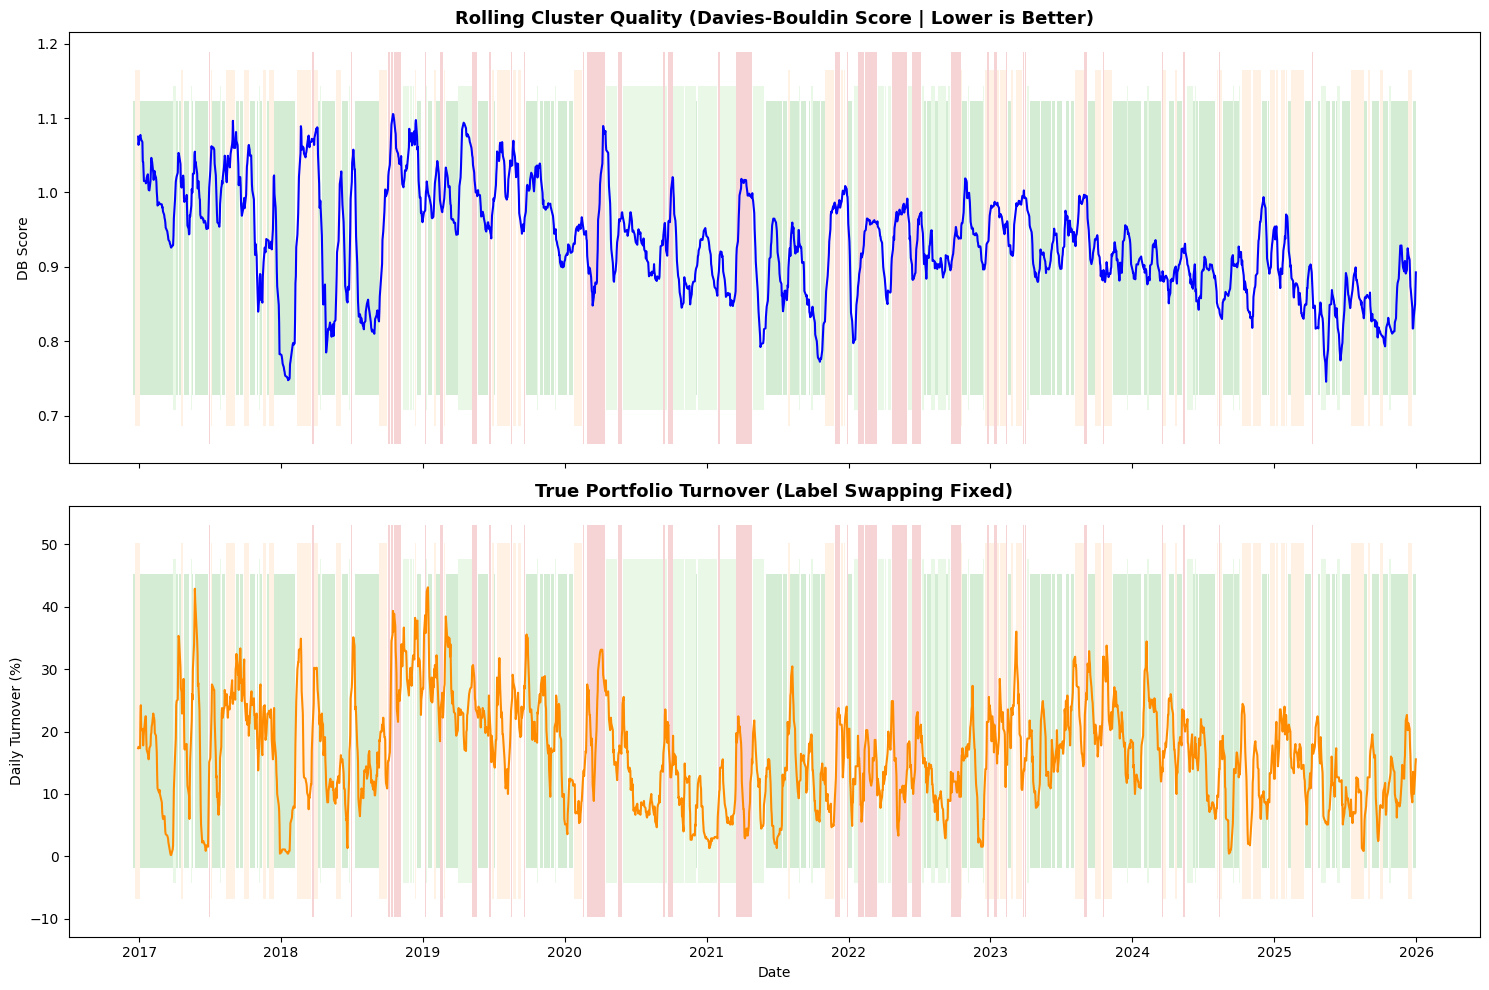

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. SETUP AND LABEL ALIGNMENT FUNCTION
# =====================================================================
# ASSUMPTION: 'macro_df' and 'returns_df' are perfectly aligned by date.
NUM_CLUSTERS = 6
NUM_PCS = 5
LOOKBACK_WINDOW = 200 # Days of history to use per rolling step

def align_labels(labels_prev, labels_curr):
    """
    Uses the Hungarian algorithm to align today's K-Means labels 
    with yesterday's labels to prevent artificial turnover.
    """
    if labels_prev is None:
        return labels_curr
        
    # Create a confusion/contingency matrix
    contingency = np.zeros((NUM_CLUSTERS, NUM_CLUSTERS))
    for i in range(len(labels_curr)):
        contingency[labels_prev[i], labels_curr[i]] += 1
        
    # We want to maximize overlap, so we minimize the negative contingency
    row_ind, col_ind = linear_sum_assignment(-contingency)
    
    # Create a mapping dictionary from old label to new label
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    
    # Apply the mapping to the current labels
    aligned_labels = np.array([mapping[label] for label in labels_curr])
    return aligned_labels

# =====================================================================
# 2. ROLLING REGIME-WISE CLUSTERING ENGINE
# =====================================================================
print("="*60)
print("RUNNING ROLLING REGIME-WISE DIAGNOSTICS (WITH LABEL ALIGNMENT)")
print("="*60)

diagnostic_records = []
prev_aligned_labels = None

# Iterate through time, starting only after we have enough historical data
for t in range(LOOKBACK_WINDOW, len(returns_df)):
    current_date = returns_df.index[t]
    current_regime = macro_df['Regime'].iloc[t]
    
    # 1. Get Regime-Specific History
    # Look at all days up to today where the regime matches today's regime
    past_regime_mask = (macro_df['Regime'].iloc[:t] == current_regime)
    regime_history = returns_df.iloc[:t][past_regime_mask]
    
    # Failsafe: If we don't have enough days of THIS regime, use standard recent window
    if len(regime_history) < 40:
        window_returns = returns_df.iloc[t - 40 : t]
    else:
        # Take the most recent 'LOOKBACK_WINDOW' days of this specific regime
        window_returns = regime_history[-LOOKBACK_WINDOW:]     
        
    # 2. PCA & K-Means
    X_scaled = StandardScaler().fit_transform(window_returns)
    pca = PCA(n_components=NUM_PCS, random_state=42)
    loadings = pca.fit(X_scaled).components_.T
    
    kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=5)
    raw_labels = kmeans.fit_predict(loadings)
    
    # 3. Align Labels to Yesterday to fix Label Switching
    aligned_labels = align_labels(prev_aligned_labels, raw_labels)
    
    # 4. Diagnostics
    db_score = davies_bouldin_score(loadings, aligned_labels)
    sil_score = silhouette_score(loadings, aligned_labels)
    
    # Calculate True Turnover (% of stocks that physically changed sectors)
    if prev_aligned_labels is not None:
        changed_stocks = np.sum(aligned_labels != prev_aligned_labels)
        turnover_rate = changed_stocks / len(aligned_labels)
    else:
        turnover_rate = 0.0
        
    prev_aligned_labels = aligned_labels
    
    diagnostic_records.append({
        'Date': current_date,
        'Regime': current_regime,
        'DB_Score': db_score,
        'Silhouette': sil_score,
        'Turnover': turnover_rate
    })

# =====================================================================
# 3. DIAGNOSTIC REPORT AGGREGATION
# =====================================================================
df_diag = pd.DataFrame(diagnostic_records).set_index('Date')

regime_names = {
    1: '1. Bull Calm', 
    2: '2. Bull Volatile', 
    3: '3. Bear Calm', 
    4: '4. Bear Volatile'
}

print("\n--- AVERAGE ROLLING METRICS PER REGIME ---")
summary_list = []
for r in [1, 2, 3, 4]:
    r_data = df_diag[df_diag['Regime'] == r]
    if len(r_data) == 0: continue
        
    summary_list.append({
        'Regime': regime_names[r],
        'Rolling_DB_Score': r_data['DB_Score'].mean(),
        'Rolling_Silhouette': r_data['Silhouette'].mean(),
        'Avg_Daily_Turnover(%)': r_data['Turnover'].mean() * 100
    })

df_summary = pd.DataFrame(summary_list).set_index('Regime')
print(df_summary.round(4))

# =====================================================================
# 4. VISUALIZING TURNOVER & CLUSTER QUALITY OVER TIME
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Colors for regimes background
bg_colors = {1: '#2ca02c', 2: '#98df8a', 3: '#ffbb78', 4: '#d62728'}

def shade_background(ax):
    for r in [1, 2, 3, 4]:
        mask = df_diag['Regime'] == r
        ax.fill_between(df_diag.index, ax.get_ylim()[0], ax.get_ylim()[1], 
                        where=mask, facecolor=bg_colors[r], alpha=0.2)

# Plot 1: Davies-Bouldin Score
# We use a 10-day rolling mean to smooth out the noise for visibility
ax1.plot(df_diag.index, df_diag['DB_Score'].rolling(10).mean(), color='blue', linewidth=1.5)
ax1.set_title("Rolling Cluster Quality (Davies-Bouldin Score | Lower is Better)", fontsize=13, fontweight='bold')
ax1.set_ylabel("DB Score")
shade_background(ax1)

# Plot 2: Daily Turnover
ax2.plot(df_diag.index, df_diag['Turnover'].rolling(10).mean() * 100, color='darkorange', linewidth=1.5)
ax2.set_title("True Portfolio Turnover (Label Swapping Fixed)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Daily Turnover (%)")
ax2.set_xlabel("Date")
shade_background(ax2)

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. SETUP AND HUNGARIAN ALGORITHM
# =====================================================================
NUM_CLUSTERS = 6
NUM_PCS = 5
EWM_SPAN = 200        # Fix 2: Exponential decay span
REBALANCE_DAYS = 25   # Fix 1: Sticky Centroid max holding period

def align_labels(labels_prev, labels_curr):
    if labels_prev is None: return labels_curr
    contingency = np.zeros((NUM_CLUSTERS, NUM_CLUSTERS))
    for i in range(len(labels_curr)):
        contingency[labels_prev[i], labels_curr[i]] += 1
    row_ind, col_ind = linear_sum_assignment(-contingency)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[label] for label in labels_curr])

# =====================================================================
# 2. EVENT-DRIVEN EWM CLUSTERING ENGINE
# =====================================================================
print("="*65)
print("RUNNING INSTITUTIONAL DIAGNOSTICS (FIX 1: STICKY, FIX 2: EWM)")
print("="*65)

diagnostic_records = []
prev_aligned_labels = None
locked_labels = None
days_since_rebalance = 0
prev_regime = None

# Start loop after initial window
for t in range(EWM_SPAN, len(returns_df)):
    current_date = returns_df.index[t]
    current_regime = macro_df['Regime'].iloc[t]
    
    # Check Rebalance Triggers (Regime Change OR 21 Days elapsed)
    trigger_rebalance = False
    if current_regime != prev_regime:
        trigger_rebalance = True
    elif days_since_rebalance >= REBALANCE_DAYS:
        trigger_rebalance = True
        
    # --- FIX 2: EWM COVARIANCE & PCA ---
    # Get all history up to today for this specific regime
    past_regime_mask = (macro_df['Regime'].iloc[:t] == current_regime)
    regime_history = returns_df.iloc[:t][past_regime_mask]
    
    if len(regime_history) < 40:
        window_returns = returns_df.iloc[t - 40 : t] # Failsafe
    else:
        window_returns = regime_history
        
    # Calculate EWM Correlation Matrix directly (Pandas handles the exponential math)
    ewm_cov = window_returns.ewm(span=EWM_SPAN, adjust=False).cov().loc[window_returns.index[-1]]
    ewm_std = np.sqrt(np.diag(ewm_cov))
    ewm_corr = ewm_cov / np.outer(ewm_std, ewm_std)
    
    # Extract Principal Components from EWM Correlation matrix
    eigenvalues, eigenvectors = np.linalg.eigh(ewm_corr)
    
    # Sort descending
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Calculate PCA Loadings (Eigenvectors * sqrt(Eigenvalues))
    loadings = eigenvectors[:, :NUM_PCS] * np.sqrt(eigenvalues[:NUM_PCS])
    
    # --- FIX 1: EVENT-DRIVEN LOGIC ---
    if trigger_rebalance or locked_labels is None:
        # Run K-Means only on Rebalance Days
        kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
        raw_labels = kmeans.fit_predict(loadings)
        
        # Align with last known clusters
        aligned_labels = align_labels(prev_aligned_labels, raw_labels)
        
        # Calculate Turnover (Spikes on this specific day, 0 on other days)
        if prev_aligned_labels is not None:
            changed_stocks = np.sum(aligned_labels != prev_aligned_labels)
            daily_turnover = changed_stocks / len(aligned_labels)
        else:
            daily_turnover = 0.0
            
        locked_labels = aligned_labels
        prev_aligned_labels = aligned_labels
        days_since_rebalance = 0 # Reset clock
    else:
        # DO NOT CLUSTER. Hold the sticky clusters from the previous rebalance.
        daily_turnover = 0.0 
        days_since_rebalance += 1
        
    # Evaluate today's continuous EWM data against our locked clusters
    db_score = davies_bouldin_score(loadings, locked_labels)
    sil_score = silhouette_score(loadings, locked_labels)
    
    prev_regime = current_regime
    
    diagnostic_records.append({
        'Date': current_date,
        'Regime': current_regime,
        'DB_Score': db_score,
        'Silhouette': sil_score,
        'Turnover': daily_turnover
    })

# =====================================================================
# 3. DIAGNOSTIC REPORT 
# =====================================================================
df_diag = pd.DataFrame(diagnostic_records).set_index('Date')

regime_names = {1: '1. Bull Calm', 2: '2. Bull Volatile', 3: '3. Bear Calm', 4: '4. Bear Volatile'}

print("\n--- AVERAGE ROLLING METRICS PER REGIME ---")
summary_list = []
for r in [1, 2, 3, 4]:
    r_data = df_diag[df_diag['Regime'] == r]
    if len(r_data) == 0: continue
        
    summary_list.append({
        'Regime': regime_names[r],
        'Rolling_DB_Score': r_data['DB_Score'].mean(),
        'Rolling_Silhouette': r_data['Silhouette'].mean(),
        # Annualized/Average daily turnover across the whole period
        'Avg_Daily_Turnover(%)': r_data['Turnover'].mean() * 100 
    })

df_summary = pd.DataFrame(summary_list).set_index('Regime')
print(df_summary.round(4))

RUNNING INSTITUTIONAL DIAGNOSTICS (FIX 1: STICKY, FIX 2: EWM)

--- AVERAGE ROLLING METRICS PER REGIME ---
                  Rolling_DB_Score  Rolling_Silhouette  Avg_Daily_Turnover(%)
Regime                                                                       
1. Bull Calm                1.0301              0.3108                 5.2446
2. Bull Volatile            1.0153              0.3325                 9.2006
3. Bear Calm                1.0845              0.2847                 8.2033
4. Bear Volatile            1.1196              0.2685                10.3968


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import pairwise_distances_argmin_min
import warnings
warnings.filterwarnings('ignore')

# ASSUMPTIONS:
# - NUM_CLUSTERS = 6
# - You have the 10-year 'returns_df' and 'macro_df'
# - We will use the static regime-wise approach here to generate your base weights per regime.

NUM_CLUSTERS = 6

def minimize_historical_var(weights, returns_matrix, alpha=5):
    """
    Objective Function: Calculates the 95% Historical VaR.
    We want SciPy to MINIMIZE this number (push the left-tail losses closer to zero).
    """
    # Calculate simulated portfolio returns using these weights
    portfolio_returns = np.dot(returns_matrix, weights)
    
    # Find the 5th percentile (95% confidence tail risk)
    # np.percentile returns a negative number for losses. 
    # We multiply by -1 to make it a positive loss figure for SciPy to minimize.
    var_95 = -np.percentile(portfolio_returns, alpha)
    return var_95

print("="*65)
print("PHASE 4: REGIME-WISE 95% VaR OPTIMIZATION (CENTROID PORTFOLIO)")
print("="*65)

# Dictionary to store our final target portfolios
regime_portfolios = {}

for target_regime in [1, 2, 3, 4]:
    # 1. Isolate Regime Data
    regime_mask = macro_df['Regime'] == target_regime
    regime_returns = returns_df[regime_mask]
    
    if len(regime_returns) < 50:
        continue # Skip if not enough data
        
    # 2. Re-calculate the specific clusters for this regime
    X_scaled = StandardScaler().fit_transform(regime_returns)
    pca = PCA(n_components=5, random_state=42)
    loadings = pca.fit(X_scaled).components_.T
    
    kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
    kmeans.fit(loadings)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    
    # 3. Find the "Medoid" (Closest Stock to Centroid) for each cluster
    medoid_stocks = []
    for i in range(NUM_CLUSTERS):
        # Get indices of stocks in this cluster
        cluster_indices = np.where(labels == i)[0]
        cluster_loadings = loadings[cluster_indices]
        
        # Find the single stock closest to the cluster's centroid
        closest_idx, _ = pairwise_distances_argmin_min([centroids[i]], cluster_loadings)
        
        # Map back to the actual stock ticker
        actual_stock_idx = cluster_indices[closest_idx[0]]
        medoid_stocks.append(returns_df.columns[actual_stock_idx])
        
    # 4. Extract only the returns of those 6 specific stocks
    centroid_returns = regime_returns[medoid_stocks].values
    
    # 5. SciPy Optimization Setup
    # Initial guess: Equal weight (1/6th each)
    init_guess = np.ones(NUM_CLUSTERS) / NUM_CLUSTERS
    
    # Bounds: No short selling (0.0 to 1.0) for each of the 6 stocks
    bounds = tuple((0.0, 1.0) for _ in range(NUM_CLUSTERS))
    
    # Constraints: The sum of all weights MUST equal 1.0 (100% invested)
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    
    # 6. Run the Optimizer
    optimal_result = minimize(
        minimize_historical_var, 
        init_guess, 
        args=(centroid_returns,), 
        method='SLSQP', 
        bounds=bounds, 
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 1000}
    )
    
    # Extract optimal weights and round them cleanly
    optimal_weights = np.round(optimal_result.x, 4)
    
    regime_portfolios[target_regime] = {
        'Stocks': medoid_stocks,
        'Weights': optimal_weights,
        'VaR_95': optimal_result.fun # The minimized VaR figure
    }

# =====================================================================
# DISPLAY OPTIMIZED PORTFOLIOS
# =====================================================================
regime_names = {1: '1. Bull Calm', 2: '2. Bull Volatile', 3: '3. Bear Calm', 4: '4. Bear Volatile'}

for regime, data in regime_portfolios.items():
    print(f"\n--- REGIME: {regime_names[regime]} ---")
    print(f"Target 95% VaR: {-data['VaR_95'] * 100:.2f}% (Max expected daily loss)")
    print("Optimal Target Weights:")
    
    # Print the specific stock and its optimal weight
    for stock, weight in zip(data['Stocks'], data['Weights']):
        # Only print stocks that actually received allocation (> 0.01%)
        if weight > 0.0001:
            print(f"  {stock}: {weight * 100:.2f}%")

PHASE 4: REGIME-WISE 95% VaR OPTIMIZATION (CENTROID PORTFOLIO)

--- REGIME: 1. Bull Calm ---
Target 95% VaR: 1.24% (Max expected daily loss)
Optimal Target Weights:
  SUNPHARMA.NS: 17.11%
  SHRIRAMFIN.NS: 12.40%
  COALINDIA.NS: 7.85%
  HCLTECH.NS: 23.41%
  TITAN.NS: 24.55%
  BAJAJFINSV.NS: 14.68%

--- REGIME: 2. Bull Volatile ---
Target 95% VaR: 1.51% (Max expected daily loss)
Optimal Target Weights:
  M&M.NS: 13.52%
  ASIANPAINT.NS: 10.28%
  DRREDDY.NS: 22.22%
  TECHM.NS: 18.38%
  POWERGRID.NS: 34.08%
  ICICIBANK.NS: 1.51%

--- REGIME: 3. Bear Calm ---
Target 95% VaR: 1.20% (Max expected daily loss)
Optimal Target Weights:
  INDUSINDBK.NS: 1.36%
  AXISBANK.NS: 7.22%
  WIPRO.NS: 28.89%
  ASIANPAINT.NS: 20.63%
  NTPC.NS: 12.11%
  CIPLA.NS: 29.79%

--- REGIME: 4. Bear Volatile ---
Target 95% VaR: 2.15% (Max expected daily loss)
Optimal Target Weights:
  SUNPHARMA.NS: 22.48%
  HINDALCO.NS: 0.07%
  HCLTECH.NS: 20.94%
  AXISBANK.NS: 1.76%
  NESTLEIND.NS: 40.65%
  ULTRACEMCO.NS: 14.10%


1. Computing Static 10-Year Portfolio (Always 100% Invested)...
2. Computing Dynamic Scaled Portfolio (Scaling Equity vs Cash)...

FINAL PORTFOLIO TEARSHEET: STATIC vs. DYNAMIC MACRO-SCALED
Metric               | Static (100% Equity) | Dynamic (Scaled)    
----------------------------------------------------------------------
Annualized Return    |               19.38% |               19.90%
Annualized Vol       |               18.03% |               11.76%
Sharpe Ratio         |                0.80  |                1.27 
Max Drawdown         |              -40.65% |              -11.99%
95% Daily VaR        |                1.57% |                1.11%

✅ Dynamic Scaling saved 28.66% of capital during market crashes.


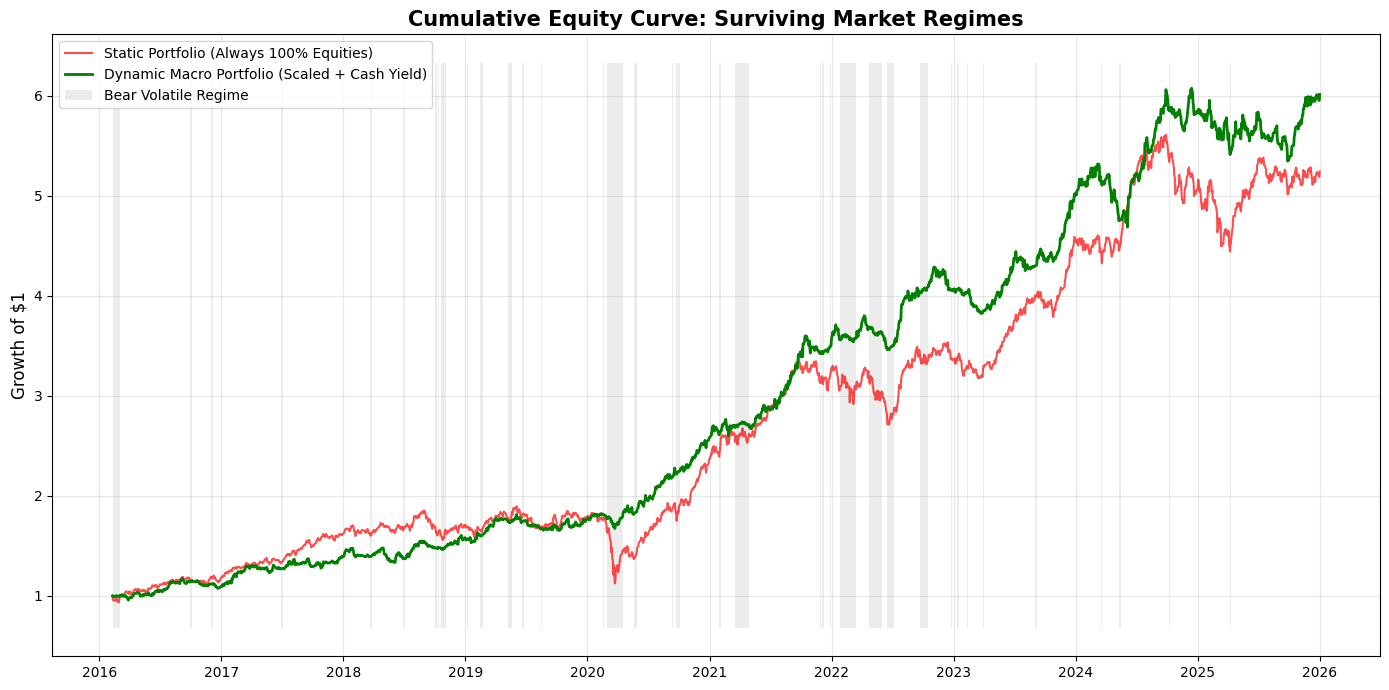

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
import warnings
warnings.filterwarnings('ignore')

NUM_CLUSTERS = 6
ALPHA = 5 # 95% Confidence Level

# --- NEW MACRO CONSIDERATIONS ---
ANNUAL_RISK_FREE_RATE = 0.05
DAILY_RF = ANNUAL_RISK_FREE_RATE / 252

# How much of the portfolio is invested in Equities vs Cash per regime?
EXPOSURE_MAP = {
    1: 1.00,  # Bull Calm: 100% Equity, 0% Cash
    2: 0.75,  # Bull Volatile: 75% Equity, 25% Cash
    3: 0.50,  # Bear Calm: 50% Equity, 50% Cash
    4: 0.25   # Bear Volatile: 25% Equity, 75% Cash
}

def minimize_var(weights, returns_matrix):
    port_returns = np.dot(returns_matrix, weights)
    return -np.percentile(port_returns, ALPHA)

def calculate_metrics(returns_series):
    """Calculates standard institutional performance metrics."""
    var_95 = -np.percentile(returns_series, ALPHA)
    ann_ret = returns_series.mean() * 252
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = (ann_ret - ANNUAL_RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0
    
    cum_returns = (1 + returns_series).cumprod()
    rolling_max = cum_returns.cummax()
    drawdown = (cum_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    return var_95, ann_ret, ann_vol, sharpe, max_dd

# =====================================================================
# 1. THE STATIC BASELINE PORTFOLIO (10-Year "Buy & Hold" @ 100% Equity)
# =====================================================================
print("1. Computing Static 10-Year Portfolio (Always 100% Invested)...")

X_static = StandardScaler().fit_transform(returns_df)
loadings_static = PCA(n_components=5, random_state=42).fit(X_static).components_.T
kmeans_static = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
labels_static = kmeans_static.fit_predict(loadings_static)

static_medoids = []
for i in range(NUM_CLUSTERS):
    idx = np.where(labels_static == i)[0]
    closest, _ = pairwise_distances_argmin_min([kmeans_static.cluster_centers_[i]], loadings_static[idx])
    static_medoids.append(returns_df.columns[idx[closest[0]]])

static_matrix = returns_df[static_medoids].values
bounds = tuple((0.0, 1.0) for _ in range(NUM_CLUSTERS))
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}

static_opt = minimize(minimize_var, np.ones(NUM_CLUSTERS)/NUM_CLUSTERS, args=(static_matrix,), 
                      method='SLSQP', bounds=bounds, constraints=constraints)

# Static portfolio is ALWAYS 100% invested, so no cash yield is added
static_portfolio_returns = pd.Series(np.dot(static_matrix, static_opt.x), index=returns_df.index)

# =====================================================================
# 2. THE DYNAMIC SCALED PORTFOLIO (Regime-Aware + Cash Yield)
# =====================================================================
print("2. Computing Dynamic Scaled Portfolio (Scaling Equity vs Cash)...")
dynamic_portfolio_returns = pd.Series(index=returns_df.index, dtype=float)

for regime in [1, 2, 3, 4]:
    regime_mask = macro_df['Regime'] == regime
    regime_data = returns_df[regime_mask]
    
    if len(regime_data) < 50: continue
        
    X_reg = StandardScaler().fit_transform(regime_data)
    loadings_reg = PCA(n_components=5, random_state=42).fit(X_reg).components_.T
    kmeans_reg = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
    labels_reg = kmeans_reg.fit_predict(loadings_reg)
    
    regime_medoids = []
    for i in range(NUM_CLUSTERS):
        idx = np.where(labels_reg == i)[0]
        closest, _ = pairwise_distances_argmin_min([kmeans_reg.cluster_centers_[i]], loadings_reg[idx])
        regime_medoids.append(returns_df.columns[idx[closest[0]]])
        
    regime_matrix = regime_data[regime_medoids].values
    regime_opt = minimize(minimize_var, np.ones(NUM_CLUSTERS)/NUM_CLUSTERS, args=(regime_matrix,), 
                          method='SLSQP', bounds=bounds, constraints=constraints)
    
    # Calculate pure equity returns for these specific cluster stocks
    equity_returns = np.dot(regime_matrix, regime_opt.x)
    
    # --- APPLY MACRO SCALING & CASH YIELD ---
    equity_weight = EXPOSURE_MAP[regime]
    cash_weight = 1.0 - equity_weight
    
    # Total Return = (Equity Return * Equity Weight) + (Daily Risk Free Rate * Cash Weight)
    scaled_returns = (equity_returns * equity_weight) + (DAILY_RF * cash_weight)
    
    dynamic_portfolio_returns.loc[regime_mask] = scaled_returns

dynamic_portfolio_returns.fillna(0, inplace=True)

# =====================================================================
# 3. OVERALL COMPARISON & TEARSHEET
# =====================================================================
stat_var, stat_ret, stat_vol, stat_sharpe, stat_dd = calculate_metrics(static_portfolio_returns)
dyn_var, dyn_ret, dyn_vol, dyn_sharpe, dyn_dd = calculate_metrics(dynamic_portfolio_returns)

print("\n" + "="*70)
print("FINAL PORTFOLIO TEARSHEET: STATIC vs. DYNAMIC MACRO-SCALED")
print("="*70)
print(f"{'Metric':<20} | {'Static (100% Equity)':<20} | {'Dynamic (Scaled)':<20}")
print("-" * 70)
print(f"{'Annualized Return':<20} | {stat_ret*100:>19.2f}% | {dyn_ret*100:>19.2f}%")
print(f"{'Annualized Vol':<20} | {stat_vol*100:>19.2f}% | {dyn_vol*100:>19.2f}%")
print(f"{'Sharpe Ratio':<20} | {stat_sharpe:>19.2f}  | {dyn_sharpe:>19.2f} ")
print(f"{'Max Drawdown':<20} | {stat_dd*100:>19.2f}% | {dyn_dd*100:>19.2f}%")
print(f"{'95% Daily VaR':<20} | {stat_var*100:>19.2f}% | {dyn_var*100:>19.2f}%")
print("="*70)

# Calculate improvement in Drawdown
dd_improvement = stat_dd - dyn_dd # (e.g., -40% - -15% = 25% capital saved)
print(f"\n✅ Dynamic Scaling saved {abs(dd_improvement)*100:.2f}% of capital during market crashes.")

# Plot the Equity Curves
plt.figure(figsize=(14, 7))
static_cum = (1 + static_portfolio_returns).cumprod()
dynamic_cum = (1 + dynamic_portfolio_returns).cumprod()

plt.plot(static_cum.index, static_cum, color='red', label='Static Portfolio (Always 100% Equities)', alpha=0.7)
plt.plot(dynamic_cum.index, dynamic_cum, color='green', label='Dynamic Macro Portfolio (Scaled + Cash Yield)', linewidth=2)

plt.title('Cumulative Equity Curve: Surviving Market Regimes', fontsize=15, fontweight='bold')
plt.ylabel('Growth of $1', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)
# Shade the Bear Volatile regimes to visually show the dynamic model preserving capital
for regime in [4]:
    mask = macro_df['Regime'] == regime
    plt.fill_between(macro_df.index, plt.ylim()[0], plt.ylim()[1], where=mask, facecolor='gray', alpha=0.15, label='Bear Volatile Regime')

# Deduplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.show()